<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana5/Exemplo_M%C3%A3o_Real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FINE-TUNING COM DUPLICAÇÃO DE DADOS E VALIDAÇÃO VISUAL
-> O dataset original de 7 fotos foi expandido para 105 fotos reais.

-> Iniciando o Treinamento Intensivo com Augmentation...
Epoch 1/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.3810 - loss: 2.2981
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.4286 - loss: 1.1114
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.4667 - loss: 1.0668
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 0.4667 - loss: 1.0533
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - accuracy: 0.6190 - loss: 0.9933
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.6000 - loss: 0.9152
Epoch 7/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.5810 - loss: 0.8413
Epoch 8/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.6190 - loss: 0.7936
Epoch 9/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - accuracy: 0.6762 - loss: 0.7403
Epoch 10/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 26

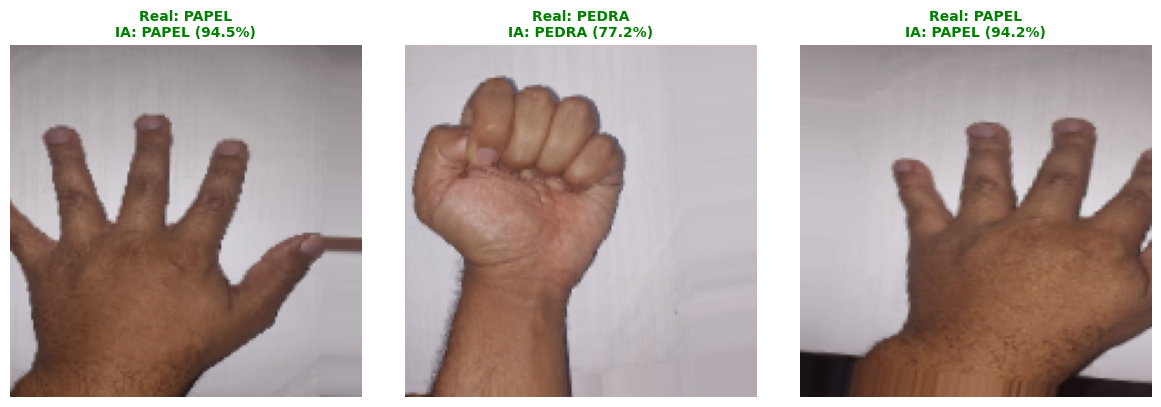

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random

print("="*75)
print("FINE-TUNING COM DUPLICAÇÃO DE DADOS E VALIDAÇÃO VISUAL")
print("="*75)

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS LOCAIS
# ==============================================================================
fotos_reais = [
    "WhatsApp Image 2026-08-27 at 15.00.58.jpeg", # 0: Pedra
    "WhatsApp Image 2026-08-27 at 15.01.08.jpeg", # 0: Pedra
    "WhatsApp Image 2026-08-27 at 15.02.31.jpeg", # 2: Tesoura
    "WhatsApp Image 2026-08-27 at 15.02.45.jpeg", # 2: Tesoura
    "WhatsApp Image 2026-08-27 at 15.02.57.jpeg", # 1: Papel
    "WhatsApp Image 2026-08-27 at 15.03.06.jpeg", # 1: Papel
    "WhatsApp Image 2026-08-27 at 15.03.26.jpeg"  # 1: Papel
]
gabaritos = [0, 0, 2, 2, 1, 1, 1]
nomes_classes = ['Pedra', 'Papel', 'Tesoura']

imagens_professor = []
for nome in fotos_reais:
    if not os.path.exists(nome):
        print(f"[ERRO] Faça o upload da foto: {nome}")
        continue
    img = tf.keras.utils.load_img(nome, target_size=(150, 150))
    imagens_professor.append(tf.keras.utils.img_to_array(img))

x_treino_base = np.array(imagens_professor)
y_treino_base = np.array(gabaritos)

# ==============================================================================
# 2. A MÁGICA DA MULTIPLICAÇÃO (DUPLICANDO OS DADOS)
# ==============================================================================
# Multiplicamos o dataset base por 15. As 7 fotos originais viram 105 fotos.
fator_multiplicacao = 15
x_treino_expandido = np.concatenate([x_treino_base] * fator_multiplicacao)
y_treino_expandido = np.concatenate([y_treino_base] * fator_multiplicacao)

print(f"-> O dataset original de {len(x_treino_base)} fotos foi expandido para {len(x_treino_expandido)} fotos reais.")

# ==============================================================================
# 3. CONSTRUINDO A CNN
# ==============================================================================
modelo_finetuning = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

modelo_finetuning.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==============================================================================
# 4. AUGMENTATION AGRESSIVO E TREINAMENTO
# ==============================================================================
gerador_pesado = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

print("\n-> Iniciando o Treinamento Intensivo com Augmentation...")
historico = modelo_finetuning.fit(
    gerador_pesado.flow(x_treino_expandido, y_treino_expandido, batch_size=8),
    epochs=15, verbose=1
)

print(f"\n[AVALIAÇÃO FINAL] Acurácia atingida no treino: {historico.history['accuracy'][-1]*100:.2f}%")

# ==============================================================================
# 5. VALIDAÇÃO VISUAL (TIRANDO A PROVA)
# ==============================================================================
print("\n-> Sorteando 3 fotos modificadas pelo Augmentation para validar a predição:")

# Pegamos um lote aleatório do gerador que tem as fotos distorcidas
lote_imagens, lote_gabaritos = next(gerador_pesado.flow(x_treino_expandido, y_treino_expandido, batch_size=3))
predicoes = modelo_finetuning.predict(lote_imagens, verbose=0)

plt.figure(figsize=(12, 4))
for i in range(3):
    ax = plt.subplot(1, 3, i + 1)

    # Imagem (convertendo de volta para int8 para exibição correta)
    img_plot = lote_imagens[i].astype("uint8")
    plt.imshow(img_plot)

    # Predição e Gabarito
    chute_idx = np.argmax(predicoes[i])
    chute_texto = nomes_classes[chute_idx]
    real_texto = nomes_classes[int(lote_gabaritos[i])]
    confianca = np.max(predicoes[i]) * 100

    cor = "green" if chute_idx == int(lote_gabaritos[i]) else "red"

    titulo = f"Real: {real_texto.upper()}\nIA: {chute_texto.upper()} ({confianca:.1f}%)"
    plt.title(titulo, color=cor, fontweight='bold', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()